# GAN — Text Generation and Image Generation

- **Part A — Text Generation** using pretrained GPT‑2
- **Part B — Image Generation** using pretrained BigGAN‑deep



---
# Part A — Text Generation (GPT-2)

Classic GANs are hard to train on text because text is discrete (no clean gradient through sampled words), so no pretrained adversarial text generator is publicly available. GPT‑2 is the standard practical pretrained generative model used here instead. It generates fluent text via next-word prediction with not a guaranteed "correct answer", so output can wander or repeat, especially on topics/dates outside its training data (pre‑2017).

### A1: Install dependencies

In [ ]:
!pip install transformers -q

### A2: Load the pretrained GPT-2 model and tokenizer

In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer, set_seed

set_seed(42)

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print("Model loaded on:", device)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded on: cpu
Number of parameters: 124439808


### A3: Text-generation function

In [ ]:
def generate_text(prompt, max_length=100, num_sequences=1, temperature=0.8, top_k=50, top_p=0.95):
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    output_sequences = model.generate(
        input_ids,
        max_length=max_length,
        num_return_sequences=num_sequences,
        no_repeat_ngram_size=2,
        do_sample=True,
        top_k=top_k,
        top_p=top_p,
        temperature=temperature,
        pad_token_id=tokenizer.eos_token_id,
    )

    return [tokenizer.decode(seq, skip_special_tokens=True) for seq in output_sequences]

### A4: Generate text from a prompt

In [ ]:
prompt = "What is AI?"
generated = generate_text(prompt, max_length=120, num_sequences=1)

for i, text in enumerate(generated):
    print(f"--- Generated Text {i+1} ---")
    print(text)
    print()

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


--- Generated Text 1 ---
What is AI?

AI was invented to solve problems that have no answer to their problems. In fact, the AI revolution has been described as a revolution in human nature and its use has become ubiquitous. A large number of people have expressed their support for AI and the technology, and most people use the computer to think, analyze and analyze the world around them. This does not mean that AI will make a huge impact, but many people do not realize that a lot of other human beings do have an interest in artificial intelligence.
. Artificial Intelligence is a powerful tool in the fight against evil



---
# Part B — Image Generation (BigGAN)

**Recap:** a GAN has a Generator (noise to image) and a Discriminator (real vs. fake), trained together adversarially. Here we use **BigGAN-deep**, DeepMind's pretrained class-conditional GAN trained on ImageNet (1000 classes), via `pytorch-pretrained-biggan`. No training happens here and we just sample noise and feed it through the already-trained Generator.

### B1: Install dependencies

In [ ]:
!pip install pytorch-pretrained-biggan -q

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### B2: Load the pretrained BigGAN model

In [ ]:
from pytorch_pretrained_biggan import BigGAN, one_hot_from_names, truncated_noise_sample, save_as_images

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

biggan_model = BigGAN.from_pretrained('biggan-deep-256')
biggan_model.to(device)
biggan_model.eval()

print("BigGAN loaded on:", device)

BigGAN loaded on: cpu


### B3: Generate images for chosen ImageNet classes

In [ ]:
truncation = 0.2

class_names = ['soccer ball', 'space shuttle', 'golden retriever']
batch_size = len(class_names)

class_vector = one_hot_from_names(class_names, batch_size=batch_size)
noise_vector = truncated_noise_sample(truncation=truncation, batch_size=batch_size)

noise_vector = torch.from_numpy(noise_vector).to(device)
class_vector = torch.from_numpy(class_vector).to(device)

with torch.no_grad():
    images_output = biggan_model(noise_vector, class_vector, truncation)

images_output = images_output.to('cpu')
print("Generated batch shape:", images_output.shape)

Generated batch shape: torch.Size([3, 3, 256, 256])


### B4: Display the generated images

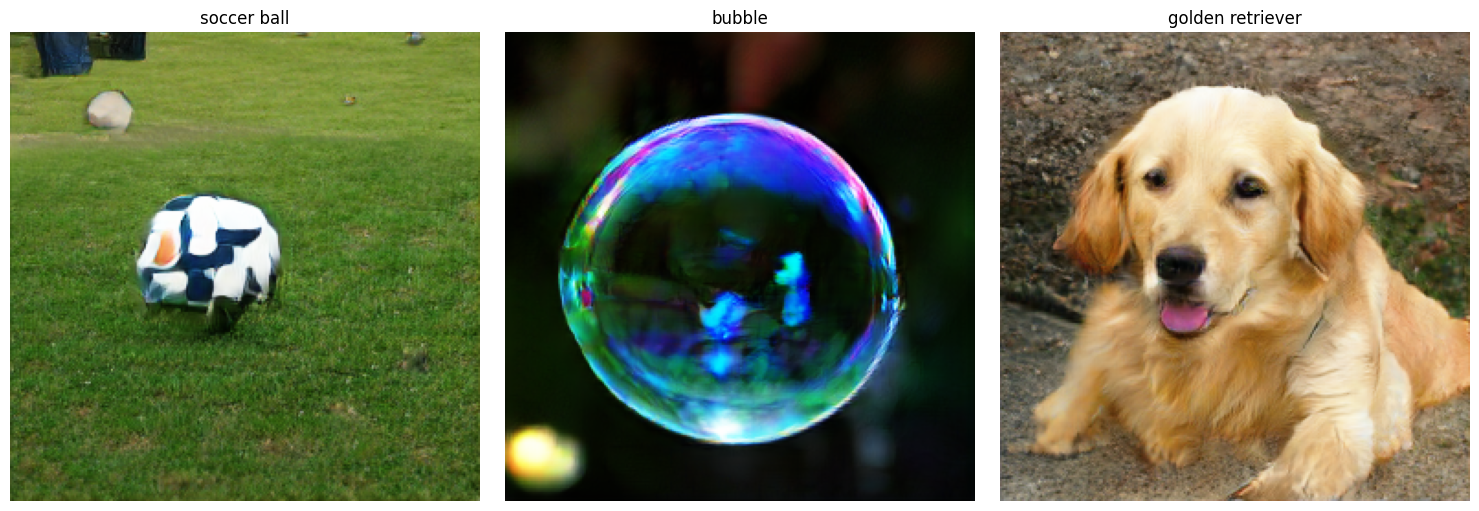

In [ ]:
import matplotlib.pyplot as plt

def show_images(images, titles):
    images = images.numpy()
    images = ((images + 1.0) / 2.0).clip(0, 1)
    images = images.transpose(0, 2, 3, 1)

    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images(images_output, class_names)